In [5]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("energydata_complete.csv")

# check shape
print("Shape:", df.shape)

df.head()


Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [6]:
# cleaning column names
# remove extra spaces and make all lowercase

df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

# checking updated column names
print("Updated columns:")
print(df.columns.tolist())


Updated columns:
['date', 'appliances', 'lights', 't1', 'rh_1', 't2', 'rh_2', 't3', 'rh_3', 't4', 'rh_4', 't5', 'rh_5', 't6', 'rh_6', 't7', 'rh_7', 't8', 'rh_8', 't9', 'rh_9', 't_out', 'press_mm_hg', 'rh_out', 'windspeed', 'visibility', 'tdewpoint', 'rv1', 'rv2']


In [7]:
# renaming columns for better readability

df = df.rename(columns={
    # target and main features
    "appliances": "energy_consumption",
    "lights": "lighting_energy",
    "press_mm_hg": "pressure",

    # indoor temperature columns
    "t1": "temp_room1",
    "t2": "temp_room2",
    "t3": "temp_room3",
    "t4": "temp_room4",
    "t5": "temp_room5",
    "t6": "temp_room6",
    "t7": "temp_room7",
    "t8": "temp_room8",
    "t9": "temp_room9",

    # indoor humidity columns
    "rh_1": "humidity_room1",
    "rh_2": "humidity_room2",
    "rh_3": "humidity_room3",
    "rh_4": "humidity_room4",
    "rh_5": "humidity_room5",
    "rh_6": "humidity_room6",
    "rh_7": "humidity_room7",
    "rh_8": "humidity_room8",
    "rh_9": "humidity_room9",

    # outdoor features
    "t_out": "temp_outdoor",
    "rh_out": "humidity_outdoor",
    "windspeed": "wind_speed",
    "visibility": "visibility_km",
    "tdewpoint": "dew_point"
})

# checking renamed columns
df.head()




,date,energy_consumption,lighting_energy,temp_room1,humidity_room1,temp_room2,humidity_room2,temp_room3,humidity_room3,temp_room4,...,temp_room9,humidity_room9,temp_outdoor,pressure,humidity_outdoor,wind_speed,visibility_km,dew_point,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [8]:
# converting date column from text to datetime format
# this helps us extract hour/day/month easily

df["date"] = pd.to_datetime(df["date"])

# checking datatype to confirm
print(df["date"].dtype)


datetime64[ns]


In [9]:
# extracting useful time-based features from date
# energy use changes by hour, weekday, etc.

df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday   # 0=Monday, 6=Sunday

# preview extracted columns
df[["date", "hour", "day", "month", "weekday"]].head()


,date,hour,day,month,weekday
0,2016-01-11 17:00:00,17,11,1,0
1,2016-01-11 17:10:00,17,11,1,0
2,2016-01-11 17:20:00,17,11,1,0
3,2016-01-11 17:30:00,17,11,1,0
4,2016-01-11 17:40:00,17,11,1,0


In [10]:
# after extracting time features, date column is not needed
df = df.drop(columns=["date"])

# rv1 and rv2 are random values (not useful for prediction)
df = df.drop(columns=["rv1", "rv2"])

# check if any missing values exist
print("Total missing values:", df.isnull().sum().sum())

# check if any duplicate rows exist
print("Duplicate rows:", df.duplicated().sum())

# final shape after preprocessing
print("Final dataset shape:", df.shape)

df.head()


Total missing values: 0
Duplicate rows: 0
Final dataset shape: (19735, 30)


,energy_consumption,lighting_energy,temp_room1,humidity_room1,temp_room2,humidity_room2,temp_room3,humidity_room3,temp_room4,humidity_room4,...,temp_outdoor,pressure,humidity_outdoor,wind_speed,visibility_km,dew_point,hour,day,month,weekday
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,17,11,1,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,17,11,1,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,17,11,1,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,17,11,1,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,17,11,1,0


In [11]:
# basic statistical summary of numeric columns
# shows mean, std, min, max, and quartiles

df.describe()


,energy_consumption,lighting_energy,temp_room1,humidity_room1,temp_room2,humidity_room2,temp_room3,humidity_room3,temp_room4,humidity_room4,...,temp_outdoor,pressure,humidity_outdoor,wind_speed,visibility_km,dew_point,hour,day,month,weekday
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,11.502002,16.057411,3.101647,2.977249
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,6.921953,8.450998,1.339200,1.985617
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.000000,1.000000,1.000000,0.000000
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,6.000000,9.000000,2.000000,1.000000
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,12.000000,16.000000,3.000000,3.000000
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,17.000000,23.000000,4.000000,5.000000
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,23.000000,31.000000,5.000000,6.000000


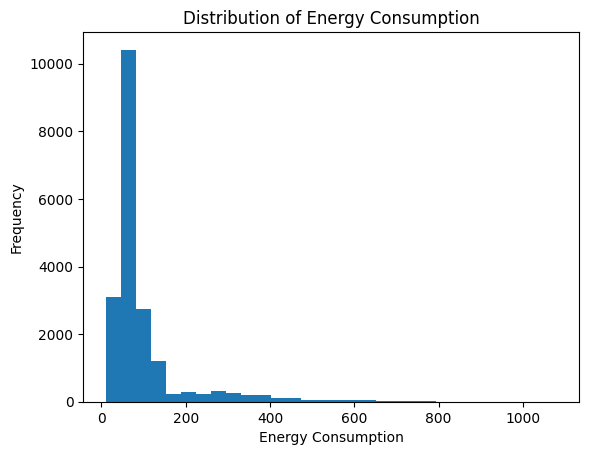

In [12]:
import matplotlib.pyplot as plt

# checking how energy consumption values are spread

plt.figure()
plt.hist(df["energy_consumption"], bins=30)

plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")

plt.show()


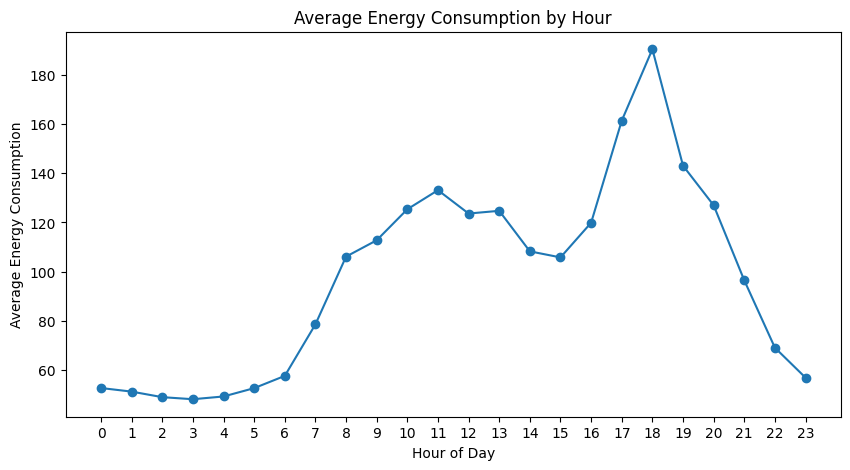

In [14]:
hourly_avg = df.groupby("hour")["energy_consumption"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption")
plt.xticks(range(0,24))
plt.show()

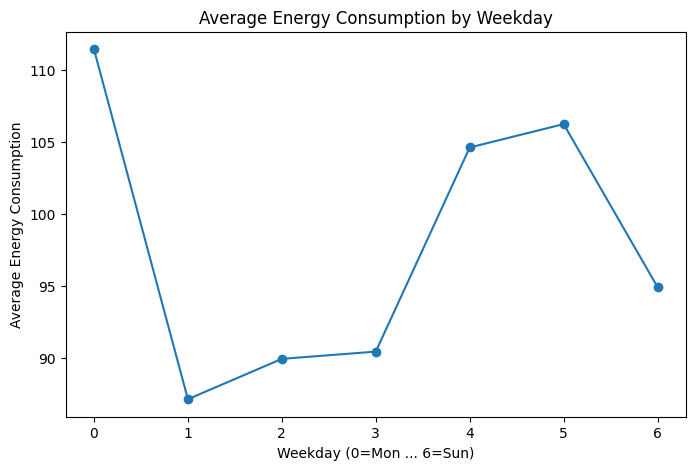

In [15]:
weekday_avg = df.groupby("weekday")["energy_consumption"].mean()

plt.figure(figsize=(8,5))
plt.plot(weekday_avg.index, weekday_avg.values, marker="o")
plt.title("Average Energy Consumption by Weekday")
plt.xlabel("Weekday (0=Mon ... 6=Sun)")
plt.ylabel("Average Energy Consumption")
plt.show()

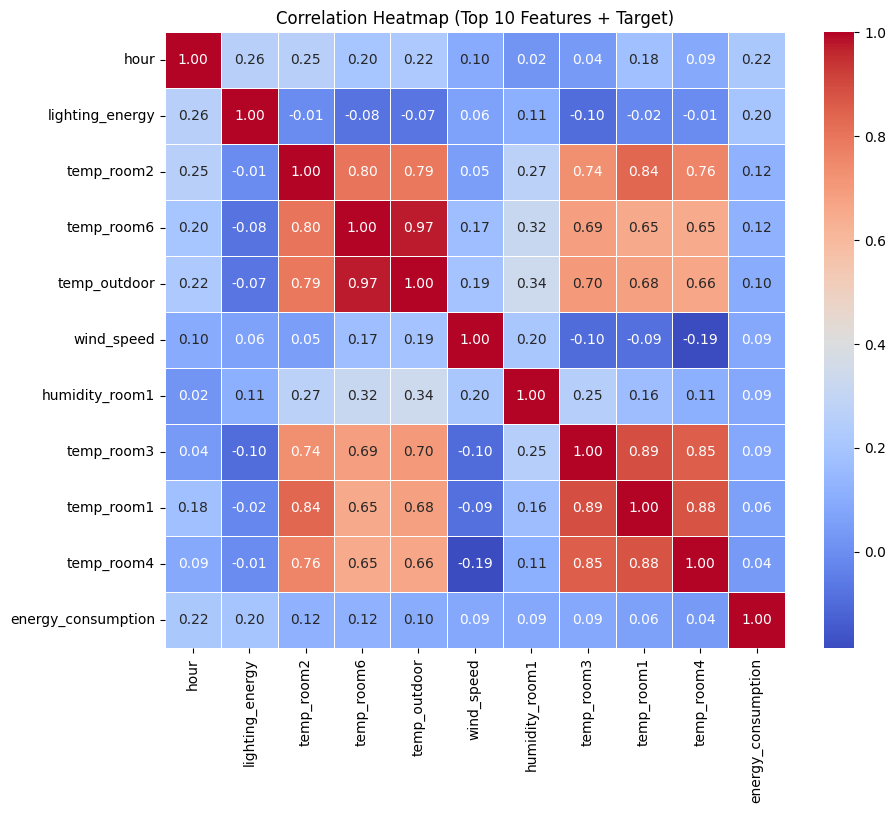

In [ ]:
import seaborn as sns

# correlation of all features with the target
corr_target = df.corr(numeric_only=True)["energy_consumption"].sort_values(ascending=False)

# selecting top 10 correlated features (excluding the target itself)
top_features = corr_target.index[1:11]

# correlation matrix for top features + target
heatmap_data = df[list(top_features) + ["energy_consumption"]].corr()

# heatmap with values shown inside boxes (annot=True)
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap (Top 10 Features + Target)")
plt.show()


In [ ]:
# target column (what we want to predict)
y = df["energy_consumption"]

# features (all columns except target)
X = df.drop(columns=["energy_consumption"])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (19735, 29)
y shape: (19735,)


In [ ]:
from sklearn.model_selection import train_test_split

# splitting into training and testing data
# test_size=0.2 means 80% train and 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape, y_train.shape)
print("Testing data :", X_test.shape, y_test.shape)


Training data: (15788, 29) (15788,)
Testing data : (3947, 29) (3947,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# scaling is needed for models like Linear Regression, SVR, Ridge, Lasso etc.

scaler = StandardScaler()

# fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)


Scaling completed
Scaled train shape: (15788, 29)
Scaled test shape : (3947, 29)


In [ ]:
# checking if any missing values exist in train/test
print("Missing in X_train:", np.isnan(X_train_scaled).sum())
print("Missing in X_test :", np.isnan(X_test_scaled).sum())

# checking target basic summary
print("\nTarget summary (train):")
print(y_train.describe())


Missing in X_train: 0
Missing in X_test : 0

Target summary (train):
count    15788.000000
mean        97.949709
std        103.136328
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: energy_consumption, dtype: float64


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# function to evaluate regression model
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# creating random forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# training model (random forest does not require scaling, but scaled data is ok)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained")


Random Forest trained


In [ ]:
# predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Performance:")
evaluate_model(y_test, y_pred_rf)



Random Forest Performance:
MAE : 30.66308588801622
RMSE: 65.67540069846531
R2  : 0.5689798147772254


In [ ]:
from xgboost import XGBRegressor

# creating xgboost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# training model
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost trained")


XGBoost trained


In [ ]:
# predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Performance:")
evaluate_model(y_test, y_pred_xgb)


XGBoost Performance:
MAE : 37.859073638916016
RMSE: 73.69639206314649
R2  : 0.45726895332336426


In [ ]:
from sklearn.svm import SVR

# SVR works best with scaling, so scaled data is required

svr_model = SVR(
    kernel="rbf",
    C=10,
    gamma="scale",
    epsilon=0.1
)

# training model
svr_model.fit(X_train_scaled, y_train)

print("SVR trained")


SVR trained


In [ ]:
# predictions
y_pred_svr = svr_model.predict(X_test_scaled)

print("SVR Performance:")
evaluate_model(y_test, y_pred_svr)


SVR Performance:
MAE : 38.44261120485963
RMSE: 92.85200380083009
R2  : 0.13846146409671523


In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "SVR"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_svr)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr))
    ],
    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_svr)
    ]
})

results


,Model,MAE,RMSE,R2
0,Random Forest,30.663086,65.675401,0.568980
1,XGBoost,37.859074,73.696392,0.457269
2,SVR,38.442611,92.852004,0.138461


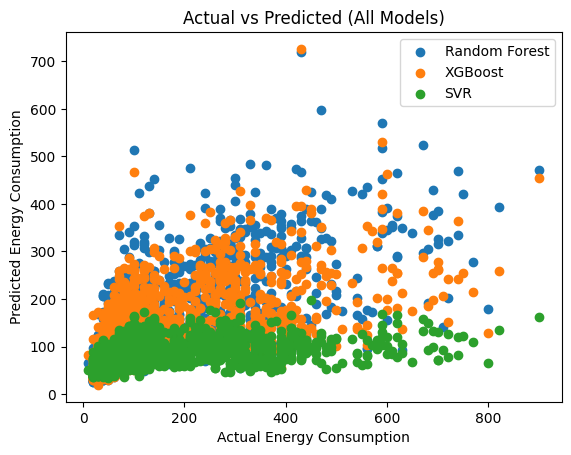

In [ ]:
import matplotlib.pyplot as plt

# plotting actual vs predicted for all models in one figure

plt.figure()

plt.scatter(y_test, y_pred_rf, label="Random Forest")
plt.scatter(y_test, y_pred_xgb, label="XGBoost")
plt.scatter(y_test, y_pred_svr, label="SVR")

plt.title("Actual vs Predicted (All Models)")
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")

plt.legend()
plt.show()


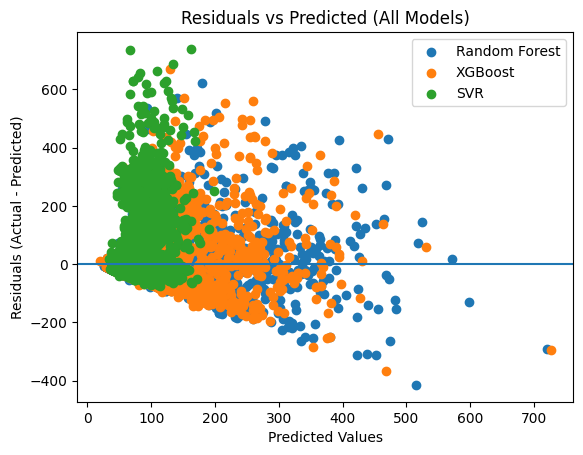

In [ ]:
# residual = actual - predicted
res_rf = y_test - y_pred_rf
res_xgb = y_test - y_pred_xgb
res_svr = y_test - y_pred_svr

# plotting residuals for all models in one figure

plt.figure()

plt.scatter(y_pred_rf, res_rf, label="Random Forest")
plt.scatter(y_pred_xgb, res_xgb, label="XGBoost")
plt.scatter(y_pred_svr, res_svr, label="SVR")

plt.axhline(y=0)  # reference line at zero error

plt.title("Residuals vs Predicted (All Models)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")

plt.legend()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# random forest model
rf = RandomForestRegressor(random_state=42)

# parameter search space
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

# randomized search
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train_scaled, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)


In [ ]:
best_rf = rf_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_scaled)

print("Random Forest Tuned Performance:")
evaluate_model(y_test, y_pred_rf_tuned)


In [ ]:
from xgboost import XGBRegressor

# xgboost model
xgb = XGBRegressor(random_state=42)

# parameter search space
xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# randomized search
xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train_scaled, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best CV RMSE:", -xgb_search.best_score_)


In [ ]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

print("XGBoost Tuned Performance:")
evaluate_model(y_test, y_pred_xgb_tuned)


In [ ]:
from sklearn.svm import SVR

# svr model
svr = SVR()

# parameter search space
svr_params = {
    "kernel": ["rbf", "linear"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "epsilon": [0.01, 0.1, 0.5, 1]
}

# randomized search
svr_search = RandomizedSearchCV(
    svr,
    param_distributions=svr_params,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

svr_search.fit(X_train_scaled, y_train)

print("Best SVR Params:", svr_search.best_params_)
print("Best CV RMSE:", -svr_search.best_score_)


In [ ]:
best_svr = svr_search.best_estimator_

y_pred_svr_tuned = best_svr.predict(X_test_scaled)

print("SVR Tuned Performance:")
evaluate_model(y_test, y_pred_svr_tuned)
